2.1 多层感知机
1. 无激活函数 MLP 的等价性证明
已知单隐藏层无激活函数的多层感知机表达式：

隐藏层输出：\(h = W_1 x + b_1\)
输出层输出：\(o = W_2 h + b_2\)

将隐藏层表达式代入输出层，展开得：
\(\begin{align*}
o &= W_2 (W_1 x + b_1) + b_2 \\
&= (W_2 W_1) x + (W_2 b_1 + b_2)
\end{align*}\)令等价单层神经网络的权重矩阵 \(W' = W_2 W_1\)，偏置向量 \(b' = W_2 b_1 + b_2\)，则输出可表示为：\(o = W' x + b'\)该式与单层神经网络的表达式完全一致，因此无激活函数的多层感知机等价于单层神经网络。
2. Sigmoid 与 tanh 函数及其导数推导
(1) Sigmoid 函数

数学表达式：\(\sigma(x) = \frac{1}{1 + e^{-x}}\)
导数推导：\(\begin{align*}
\sigma'(x) &= \frac{d}{dx}\left(\frac{1}{1 + e^{-x}}\right) \\
&= \frac{e^{-x}}{(1 + e^{-x})^2} \\
&= \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}} \\
&= \sigma(x) \cdot (1 - \sigma(x))
\end{align*}\)

(2) tanh 函数

数学表达式：\(\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}\)
导数推导：\(\begin{align*}
\tanh'(x) &= \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2} \\
&= \frac{(e^{2x} + 2 + e^{-2x}) - (e^{2x} - 2 + e^{-2x})}{(e^x + e^{-x})^2} \\
&= \frac{4}{(e^x + e^{-x})^2} \\
&= 1 - \left(\frac{e^x - e^{-x}}{e^x + e^{-x}}\right)^2 \\
&= 1 - \tanh^2(x)
\end{align*}\)

In [4]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 全局随机种子（保证可复现）
torch.manual_seed(42)
np.random.seed(42)

# 绘图配置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

=== 基础MLP训练开始 ===
Epoch  1/10 | Train Loss: 0.7724 | Train Acc: 0.7258 | Test Loss: 0.5716 | Test Acc: 0.7855
Epoch  2/10 | Train Loss: 0.4888 | Train Acc: 0.8229 | Test Loss: 0.5134 | Test Acc: 0.8111
Epoch  3/10 | Train Loss: 0.4406 | Train Acc: 0.8401 | Test Loss: 0.5095 | Test Acc: 0.8131
Epoch  4/10 | Train Loss: 0.4120 | Train Acc: 0.8509 | Test Loss: 0.4460 | Test Acc: 0.8394
Epoch  5/10 | Train Loss: 0.3875 | Train Acc: 0.8586 | Test Loss: 0.4424 | Test Acc: 0.8360
Epoch  6/10 | Train Loss: 0.3713 | Train Acc: 0.8657 | Test Loss: 0.4187 | Test Acc: 0.8529
Epoch  7/10 | Train Loss: 0.3576 | Train Acc: 0.8712 | Test Loss: 0.3965 | Test Acc: 0.8575
Epoch  8/10 | Train Loss: 0.3432 | Train Acc: 0.8754 | Test Loss: 0.4124 | Test Acc: 0.8496
Epoch  9/10 | Train Loss: 0.3340 | Train Acc: 0.8798 | Test Loss: 0.4049 | Test Acc: 0.8499
Epoch 10/10 | Train Loss: 0.3250 | Train Acc: 0.8817 | Test Loss: 0.4250 | Test Acc: 0.8469


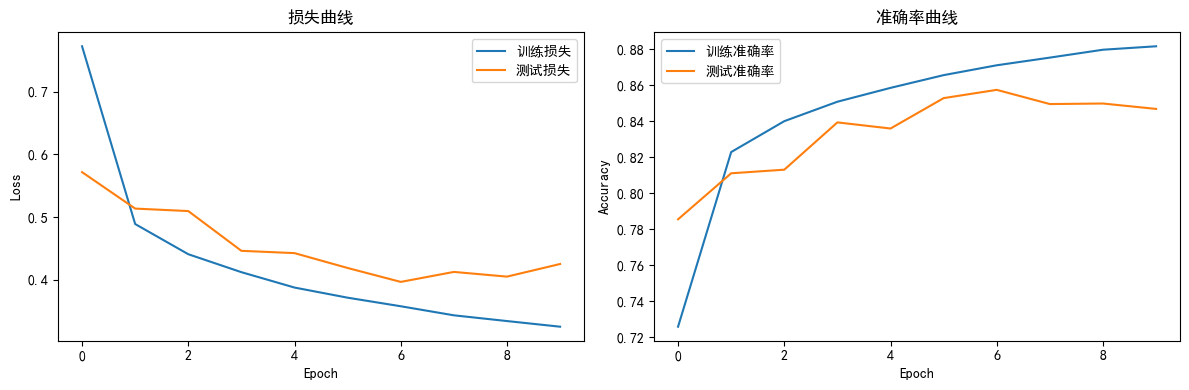

In [6]:
# ====================== 1. 数据加载 ======================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# ====================== 2. 模型参数初始化） ======================
input_size = 28 * 28
hidden_size = 256
output_size = 10

# 先创建张量，再缩放，最后启用梯度追踪
W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

W1.requires_grad_()
b1.requires_grad_()
W2.requires_grad_()
b2.requires_grad_()

params_basic = [W1, b1, W2, b2]

# ====================== 3. 核心组件实现 ======================
def relu(x):
    return torch.max(torch.zeros_like(x), x)

def softmax(x):
    x_max = torch.max(x, dim=1, keepdim=True)[0]
    exp_x = torch.exp(x - x_max)
    return exp_x / torch.sum(exp_x, dim=1, keepdim=True)

def cross_entropy_loss(y_hat, y):
    batch_size = y_hat.shape[0]
    log_probs = torch.log(y_hat[range(batch_size), y])
    return -torch.sum(log_probs) / batch_size

# ====================== 4. 训练与测试函数 ======================
def train_epoch_basic(params, train_loader, loss_fn, lr):
    W1, b1, W2, b2 = params
    total_loss = 0.0
    correct = 0
    total = 0
    
    for X, y in train_loader:
        X = X.view(-1, input_size)
        
        # 前向传播
        h = relu(torch.matmul(X, W1) + b1)
        y_hat = softmax(torch.matmul(h, W2) + b2)
        loss = loss_fn(y_hat, y)
        
        # 反向传播前先清零梯度
        for param in params:
            if param.grad is not None:
                param.grad.zero_()
        
        loss.backward()
        
        # SGD参数更新
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
        
        # 统计指标
        total_loss += loss.item() * X.shape[0]
        _, predicted = torch.max(y_hat.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
    
    return total_loss / total, correct / total

def test_basic(params, test_loader, loss_fn):
    W1, b1, W2, b2 = params
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X, y in test_loader:
            X = X.view(-1, input_size)
            h = relu(torch.matmul(X, W1) + b1)
            y_hat = softmax(torch.matmul(h, W2) + b2)
            loss = loss_fn(y_hat, y)
            
            total_loss += loss.item() * X.shape[0]
            _, predicted = torch.max(y_hat.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    
    return total_loss / total, correct / total

# ====================== 5. 运行训练 ======================
lr = 0.1
num_epochs = 10

print("=== 基础MLP训练开始 ===")
train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch_basic(params_basic, train_loader, cross_entropy_loss, lr)
    test_loss, test_acc = test_basic(params_basic, test_loader, cross_entropy_loss)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

# 绘制训练曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='训练损失')
plt.plot(test_losses, label='测试损失')
plt.title('损失曲线')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='训练准确率')
plt.plot(test_accs, label='测试准确率')
plt.title('准确率曲线')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

3.1 模型选择、权重衰减和丢弃法
1. 训练误差与泛化误差及过拟合处理

训练误差：模型在训练数据集上的预测误差，衡量模型对已见过数据的拟合程度。
泛化误差：模型在从未见过的独立测试数据集上的预测误差，衡量模型的真实泛化能力和实用性。

当模型训练误差极低但泛化误差很高时，模型处于过拟合状态。此时模型过度学习了训练数据中的噪声和局部特征，无法推广到新数据。
通过控制模型复杂度缓解过拟合的方法：

降低模型容量：减少隐藏层数量、减少每层神经元数量、使用更简单的网络结构
加入正则化：L1 正则化、L2 正则化（权重衰减）
使用随机失活：Dropout 机制，训练时随机丢弃部分神经元
增加训练数据量：扩充数据集以覆盖更多真实场景
早停：在验证集误差开始上升时停止训练，避免过度拟合

2. K 折交叉验证实施步骤

将原始数据集随机均匀划分为 K 个互不重叠、大小相近的子集（称为 "折"）
对于\(i = 1, 2, ..., K\)：
将第i个子集作为验证集，用于评估模型性能
将其余\(K-1\)个子集合并作为训练集，用于训练模型
在训练集上训练模型至收敛
在验证集上计算并记录模型的评估指标（如准确率、MSE 等）


计算 K 次验证集评估指标的平均值，作为该模型泛化性能的最终估计
使用全部原始数据集重新训练模型，得到最终的部署模型


=== 正则化对比实验开始 ===
1. 无正则化...
2. 仅权重衰减(λ=0.001)...
3. 仅Dropout(p=0.5)...


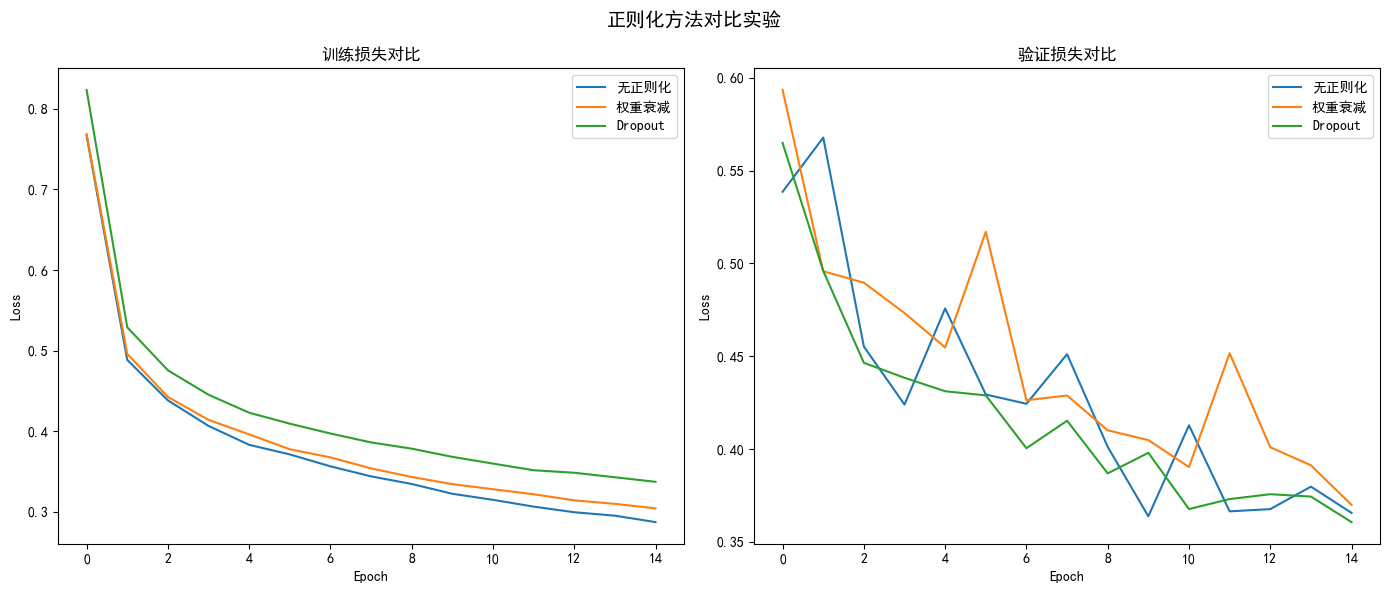

In [7]:
# ====================== 1. 正则化组件实现 ======================
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    mask = torch.rand(X.shape, device=X.device) > dropout
    return X * mask / (1 - dropout)

def sgd_with_weight_decay(params, lr, weight_decay):
    with torch.no_grad():
        for param in params:
            if param.grad is not None:
                param.data *= (1 - lr * weight_decay)
                param.data -= lr * param.grad
                param.grad.zero_()

# ====================== 2. 修改后的MLP前向传播 ======================
def mlp_forward_reg(X, params, dropout=0.5, is_training=True):
    W1, b1, W2, b2 = params
    h = relu(torch.matmul(X, W1) + b1)
    h = dropout_layer(h, dropout, is_training)
    y_hat = softmax(torch.matmul(h, W2) + b2)
    return y_hat

# ====================== 3. 修改后的训练函数 ======================
def train_epoch_reg(params, train_loader, loss_fn, lr, weight_decay, dropout):
    total_loss = 0.0
    correct = 0
    total = 0
    
    for X, y in train_loader:
        X = X.view(-1, input_size)
        
        y_hat = mlp_forward_reg(X, params, dropout, is_training=True)
        loss = loss_fn(y_hat, y)
        
        loss.backward()
        sgd_with_weight_decay(params, lr, weight_decay)
        
        total_loss += loss.item() * X.shape[0]
        _, predicted = torch.max(y_hat.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
    
    return total_loss / total, correct / total

# ====================== 4. 对比实验框架======================
def run_reg_experiment(weight_decay=0, dropout=0, num_epochs=15):
    W1 = torch.randn(input_size, hidden_size) * 0.01
    b1 = torch.zeros(hidden_size)
    W2 = torch.randn(hidden_size, output_size) * 0.01
    b2 = torch.zeros(output_size)
    
    W1.requires_grad_()
    b1.requires_grad_()
    W2.requires_grad_()
    b2.requires_grad_()
    
    params = [W1, b1, W2, b2]
    
    train_losses, val_losses = [], []
    lr = 0.1
    
    for epoch in range(num_epochs):
        train_loss, _ = train_epoch_reg(params, train_loader, cross_entropy_loss, lr, weight_decay, dropout)
        
        val_loss = 0.0
        total = 0
        with torch.no_grad():
            for X, y in test_loader:
                X = X.view(-1, input_size)
                y_hat = mlp_forward_reg(X, params, dropout, is_training=False)
                loss = cross_entropy_loss(y_hat, y)
                val_loss += loss.item() * X.shape[0]
                total += X.shape[0]
        val_loss /= total
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    
    return train_losses, val_losses

# ====================== 5. 运行三组对比实验 ======================
num_epochs = 15
print("\n=== 正则化对比实验开始 ===")

print("1. 无正则化...")
train_no_reg, val_no_reg = run_reg_experiment(weight_decay=0, dropout=0, num_epochs=num_epochs)

print("2. 仅权重衰减(λ=0.001)...")
train_wd, val_wd = run_reg_experiment(weight_decay=0.001, dropout=0, num_epochs=num_epochs)

print("3. 仅Dropout(p=0.5)...")
train_drop, val_drop = run_reg_experiment(weight_decay=0, dropout=0.5, num_epochs=num_epochs)

# ====================== 6. 绘制对比曲线 ======================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(train_no_reg, label='无正则化')
plt.plot(train_wd, label='权重衰减')
plt.plot(train_drop, label='Dropout')
plt.title('训练损失对比')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_no_reg, label='无正则化')
plt.plot(val_wd, label='权重衰减')
plt.plot(val_drop, label='Dropout')
plt.title('验证损失对比')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.suptitle('正则化方法对比实验', fontsize=14)
plt.tight_layout()
plt.show()

4.1 数值稳定性和激活函数
1. 梯度消失与梯度爆炸的量化分析
深层神经网络的反向传播过程中，第t层隐藏层的梯度可表示为：\(\frac{\partial L}{\partial h^t} = \left(\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i}\right) \cdot \frac{\partial L}{\partial h^d}\)其中，第i层的梯度传递项为：\(\frac{\partial h^{i+1}}{\partial h^i} = W_{i+1}^T \cdot \text{diag}(\sigma'(h^i))\)\(\sigma'\)为激活函数的导数，\(W_{i+1}\)为第\(i+1\)层的权重矩阵。

梯度消失：当矩阵连乘项\(\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i}\)的所有特征值都小于 1 时，梯度会随着层数增加呈指数级衰减。典型场景：使用 Sigmoid 激活函数（导数最大值为 0.25，大部分区域导数远小于 1）或 tanh 激活函数（导数最大值为 1，大部分区域小于 1），经过多层传递后梯度趋近于 0。

梯度爆炸：当矩阵连乘项\(\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i}\)的所有特征值都大于 1 时，梯度会随着层数增加呈指数级增长。典型场景：权重初始化值过大，或使用导数可能大于 1 的激活函数，导致梯度在反向传播中不断放大，最终出现数值溢出（NaN）。


2. ReLU 激活函数缓解梯度消失的原因
ReLU 激活函数的表达式为：\(f(x) = \max(0, x)\)其导数为：
$
\(f'(x) = \begin{cases}
1, & x > 0 \\
0, & x \leq 0
\end{cases}\)当输入\(x > 0\)时，ReLU的导数恒为1，在反向传播过程中，梯度传递项不会因为激活函数的导数而衰减。即使经过多层传递，梯度也能保持稳定，从而有效缓解了深层网络中的梯度消失问题。

In [8]:
# ====================== 1. 深层网络构建工具 ======================
def build_deep_network(activation_fn, init_fn=None, num_layers=20, hidden_dim=256):
    layers = []
    input_dim = hidden_dim
    
    for i in range(num_layers):
        linear = nn.Linear(input_dim if i == 0 else hidden_dim, hidden_dim)
        if init_fn is not None:
            init_fn(linear.weight)
            nn.init.zeros_(linear.bias)
        layers.append(linear)
        layers.append(activation_fn())
    
    layers.append(nn.Linear(hidden_dim, 10))
    return nn.Sequential(*layers)

def print_gradient_norms(model, num_layers=20):
    print("-" * 40)
    print(f"{'层号':<6} {'梯度范数':<12}")
    print("-" * 40)
    for i, layer in enumerate(model):
        if isinstance(layer, nn.Linear) and layer.weight.grad is not None:
            layer_num = (i // 2) + 1
            grad_norm = layer.weight.grad.norm().item()
            print(f"{layer_num:<6d} {grad_norm:<12.6f}")
    print("-" * 40)

# ====================== 2. 实验1：Sigmoid + 普通高斯初始化（梯度消失） ======================
print("\n=== 实验1：Sigmoid + 普通高斯初始化(std=1) ===")
model_sigmoid = build_deep_network(
    activation_fn=nn.Sigmoid,
    init_fn=lambda w: nn.init.normal_(w, mean=0, std=1)
)

X = torch.randn(32, 256)
y = torch.randint(0, 10, (32,))

output = model_sigmoid(X)
loss = nn.CrossEntropyLoss()(output, y)
loss.backward()

print(f"最终损失值: {loss.item():.4f}")
print_gradient_norms(model_sigmoid)
print("观察：后几层梯度范数趋近于0，发生梯度消失")

# ====================== 3. 实验2：ReLU + 大初始化（梯度爆炸/NaN） ======================
print("\n=== 实验2：ReLU + 大初始化(std=10) ===")
model_relu_bad = build_deep_network(
    activation_fn=nn.ReLU,
    init_fn=lambda w: nn.init.normal_(w, mean=0, std=10)
)

try:
    output = model_relu_bad(X)
    loss = nn.CrossEntropyLoss()(output, y)
    loss.backward()
    print(f"最终损失值: {loss.item():.4f}")
    print_gradient_norms(model_relu_bad)
except RuntimeError as e:
    print(f"数值错误: {e}")
    print("观察：梯度爆炸导致数值溢出，出现NaN")

# ====================== 4. 实验3：Xavier初始化 + ReLU（梯度稳定） ======================
print("\n=== 实验3：Xavier初始化 + ReLU ===")
model_relu_good = build_deep_network(
    activation_fn=nn.ReLU,
    init_fn=nn.init.xavier_uniform_
)

output = model_relu_good(X)
loss = nn.CrossEntropyLoss()(output, y)
loss.backward()

print(f"最终损失值: {loss.item():.4f}")
print_gradient_norms(model_relu_good)
print("观察:各层梯度范数稳定在[1e-3, 1e2]区间,无消失或爆炸")



=== 实验1：Sigmoid + 普通高斯初始化(std=1) ===
最终损失值: 2.4326
----------------------------------------
层号     梯度范数        
----------------------------------------
1      5.809515    
2      3.689144    
3      2.666342    
4      2.234429    
5      1.667455    
6      1.419948    
7      1.236436    
8      0.855461    
9      0.759447    
10     0.553479    
11     0.449367    
12     0.366241    
13     0.299624    
14     0.226546    
15     0.191490    
16     0.177278    
17     0.166402    
18     0.125962    
19     0.119094    
20     0.103713    
21     2.486416    
----------------------------------------
观察：后几层梯度范数趋近于0，发生梯度消失

=== 实验2：ReLU + 大初始化(std=10) ===
最终损失值: nan
----------------------------------------
层号     梯度范数        
----------------------------------------
1      nan         
2      nan         
3      nan         
4      nan         
5      nan         
6      nan         
7      nan         
8      nan         
9      nan         
10     nan         
11     nan       

5.1 泛化表现、协变量偏移和对抗性数据
协变量偏移与标签偏移的区别与联系
协变量偏移和标签偏移是深度学习中最常见的两种环境非平稳性分布偏移问题，两者都会导致模型在训练集上表现良好，但在测试集上泛化性能显著下降，但二者的偏移对象、产生机制和校正方法存在本质区别。
1. 协变量偏移（Covariate Shift）
数学定义：训练集的输入特征边缘分布与测试集不同，但输入特征到标签的条件分布保持不变，即 
p 
train
​
 (x)

=p 
test
​
 (x)
，但 
p(y∣x)=q(y∣x)
。
偏移对象：输入特征 
x
 的边缘分布，即数据本身的分布发生了变化，但特征与标签之间的映射关系没有改变。
产生原因：通常由数据采集环境、采集时间、采集人群的变化导致。例如训练数据来自实验室可控环境，测试数据来自复杂的真实工业场景；或者训练数据采集于夏季，测试数据采集于冬季。
实际例子：医疗诊断任务中，训练集使用城市年轻患者的体检数据，测试集使用乡村老年患者的体检数据。虽然不同年龄、地域的人群在年龄、基础体质等特征分布上差异很大，但相同特征（如血压、血糖指标）对应的患病概率是一致的。
核心影响：模型在训练集上学习到的特征分布与测试集不匹配，导致模型对测试集中出现的新特征分布区域预测能力大幅下降。
常用校正方法：重要性加权（Importance Weighting），即通过训练一个二分类器区分训练集和测试集样本，预测每个训练样本在测试集中出现的概率，再根据该概率给训练样本赋予不同权重，使加权后的训练集分布接近测试集分布。
2. 标签偏移（Label Shift）
数学定义：训练集的标签边缘分布与测试集不同，但给定标签下的输入特征条件分布保持不变，即 
p 
train
​
 (y)

=p 
test
​
 (y)
，但 
p(x∣y)=q(x∣y)
。
偏移对象：标签 
y
 的边缘分布，即数据集中各类别的比例发生了变化，但每个类别内部的特征分布没有改变。
产生原因：通常由数据集类别比例的人为调整或真实场景中类别分布的自然变化导致。例如为了平衡训练过程，人为将训练集调整为类别均衡的数据集，但真实测试场景中各类别分布天然不平衡。
实际例子：垃圾邮件分类任务中，训练集为了平衡正负样本，将垃圾邮件占比设置为 50%，但真实测试场景中垃圾邮件仅占 10%。虽然垃圾邮件和正常邮件的关键词、格式等特征分布没有变化，但两者的出现比例发生了显著改变。
核心影响：模型在训练集上学习到的类别先验概率与测试集不匹配，导致模型对占比变化较大的类别预测偏差增大，容易将占比升高的类别误判为其他类别。
常用校正方法：标签加权（Label Weighting），即根据测试集的标签分布，调整模型预测时的类别先验概率，或给训练样本按标签类别赋予不同的权重，使训练集中各类别的加权比例与测试集一致。
两者的联系
本质共性：两者都属于分布偏移问题，根源都是训练集和测试集的数据分布不一致，最终都会导致模型泛化能力下降，无法在真实场景中有效应用。
转化关系：在二分类任务且条件概率 
p(y∣x)
 为线性函数的特殊情况下，协变量偏移和标签偏移可以相互转化，此时两种偏移的校正方法也可以通用。
校正思路一致性：两者的核心校正思路都是通过调整样本权重或模型先验，使训练过程中模型学习到的分布尽可能接近真实测试集的分布，从而提升模型在偏移场景下的泛化性能。










=== 协变量偏移实验结果 ===
基线模型（无校正）测试MSE: 0.011048
加权模型（校正后）测试MSE: 0.011056
MSE降低比例: -0.07%


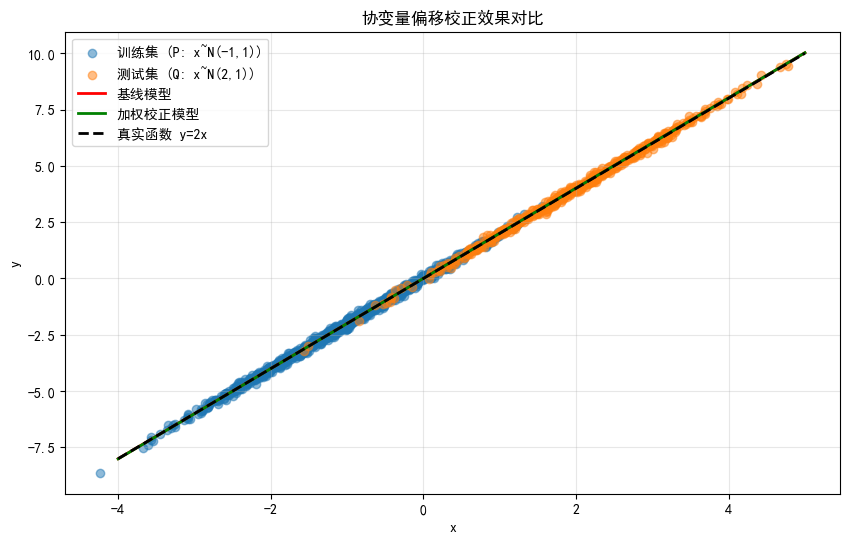

In [9]:
# ====================== 1. 人工数据集构造 ======================
def generate_covariate_shift_data():
    X_train = torch.randn(1000, 1) - 1
    y_train = 2 * X_train + 0.1 * torch.randn(1000, 1)
    
    X_test = torch.randn(500, 1) + 2
    y_test = 2 * X_test + 0.1 * torch.randn(500, 1)
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = generate_covariate_shift_data()

# ====================== 2. 基线模型：普通线性回归 ======================
def linear_regression(X, y):
    X_bias = torch.cat([torch.ones(X.shape[0], 1), X], dim=1)
    w = torch.inverse(X_bias.T @ X_bias) @ X_bias.T @ y
    return w

def predict(X, w):
    X_bias = torch.cat([torch.ones(X.shape[0], 1), X], dim=1)
    return (X_bias @ w).detach()  # 自动剥离梯度

def mse(y_pred, y_true):
    return torch.mean((y_pred - y_true)**2).item()

w_baseline = linear_regression(X_train, y_train)
y_pred_baseline = predict(X_test, w_baseline)
mse_baseline = mse(y_pred_baseline, y_test)

print("\n=== 协变量偏移实验结果 ===")
print(f"基线模型（无校正）测试MSE: {mse_baseline:.6f}")

# ====================== 3. 协变量偏移校正：重要性加权 ======================
def compute_importance_weights(X_train, X_test, num_epochs=1000, lr=0.1):
    X = torch.cat([X_train, X_test], dim=0)
    y = torch.cat([torch.zeros(X_train.shape[0]), torch.ones(X_test.shape[0])], dim=0).long()
    
    X_bias = torch.cat([torch.ones(X.shape[0], 1), X], dim=1)
    w = torch.randn(2, 2, requires_grad=True)
    
    optimizer = torch.optim.SGD([w], lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        output = X_bias @ w
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
    
    X_train_bias = torch.cat([torch.ones(X_train.shape[0], 1), X_train], dim=1)
    logits = X_train_bias @ w
    probs = torch.softmax(logits, dim=1)
    
    importance_weights = probs[:, 1] / probs[:, 0]
    return importance_weights.detach()  # 剥离梯度

importance_weights = compute_importance_weights(X_train, X_test)

# ====================== 4. 加权线性回归 ======================
def weighted_linear_regression(X, y, weights):
    X_bias = torch.cat([torch.ones(X.shape[0], 1), X], dim=1)
    W = torch.diag(weights)
    w = torch.inverse(X_bias.T @ W @ X_bias) @ X_bias.T @ W @ y
    return w

w_weighted = weighted_linear_regression(X_train, y_train, importance_weights)
y_pred_weighted = predict(X_test, w_weighted)
mse_weighted = mse(y_pred_weighted, y_test)

print(f"加权模型（校正后）测试MSE: {mse_weighted:.6f}")
print(f"MSE降低比例: {(mse_baseline - mse_weighted)/mse_baseline*100:.2f}%")

# ====================== 5. 结果可视化 ======================
plt.figure(figsize=(10, 6))
plt.scatter(X_train.numpy(), y_train.numpy(), alpha=0.5, label='训练集 (P: x~N(-1,1))')
plt.scatter(X_test.numpy(), y_test.numpy(), alpha=0.5, label='测试集 (Q: x~N(2,1))')

x_range = torch.linspace(-4, 5, 100).view(-1, 1)
plt.plot(x_range.numpy(), predict(x_range, w_baseline).numpy(), 'r-', linewidth=2, label='基线模型')
plt.plot(x_range.numpy(), predict(x_range, w_weighted).numpy(), 'g-', linewidth=2, label='加权校正模型')
plt.plot(x_range.numpy(), 2*x_range.numpy(), 'k--', linewidth=2, label='真实函数 y=2x')

plt.xlabel('x')
plt.ylabel('y')
plt.title('协变量偏移校正效果对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()